In [1]:
# ============================================================
# PHASE 19B — EXTERNAL-SUPPORTED NEGATIVE AUDIT
# ============================================================
# Goal:
# Turn Phase 19's weak external validation into a useful label-quality audit.
#
# Why:
# Phase 19 showed that several genes labelled as negatives are present in
# independent T2D / beta-cell / drug-target / OXPHOS evidence sets.
#
# This phase:
# 1. Audits external-supported genes currently labelled negative.
# 2. Tests whether these external-supported negatives receive higher model
#    scores than ordinary negatives.
# 3. Computes Top-N recovery among negative-labelled genes only.
# 4. Creates relabel-candidate tables.
# 5. Produces manuscript-safe wording:
#    "external validation is supportive but not confirmatory; labels are incomplete."
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 400)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE19_DIR = PROJECT_DIR / "model" / "phase19_external_independent_gene_set_validation"

PHASE19B_DIR = PROJECT_DIR / "model" / "phase19b_external_supported_negative_audit"
RESULT_DIR = PHASE19B_DIR / "results"
FIGURE_DIR = PHASE19B_DIR / "figures"
EXCEL_DIR = PHASE19B_DIR / "excel"
REPORT_DIR = PHASE19B_DIR / "reports"

for d in [PHASE19B_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 19B output:", PHASE19B_DIR)

Mounted at /content/drive
Phase 19B output: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def empirical_p_value(observed, random_values, alternative="greater"):
    random_values = np.asarray(random_values)

    if alternative == "greater":
        return (np.sum(random_values >= observed) + 1) / (len(random_values) + 1)

    if alternative == "less":
        return (np.sum(random_values <= observed) + 1) / (len(random_values) + 1)

    raise ValueError("alternative must be greater or less")


def safe_mannwhitneyu(a, b, alternative="two-sided"):
    try:
        stat, p = mannwhitneyu(a, b, alternative=alternative)
        return stat, p
    except Exception:
        return np.nan, np.nan


def bootstrap_ci_mean(values, n_boot=3000, seed=42, ci=95):
    rng_local = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)

    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng_local.choice(values, size=len(values), replace=True)))

    alpha = (100 - ci) / 2
    return (
        float(np.percentile(boots, alpha)),
        float(np.percentile(boots, 100 - alpha))
    )

In [3]:
# ============================================================
# LOAD PHASE 19 OUTPUTS
# ============================================================

rank_path = PHASE19_DIR / "results" / "phase19_gene_level_oof_rankings_by_model.csv"
external_set_path = PHASE19_DIR / "results" / "phase19_external_gene_set_long.csv"
external_ranked_path = PHASE19_DIR / "results" / "phase19_external_supported_genes_ranked_by_model.csv"
external_negative_path = PHASE19_DIR / "results" / "phase19_external_supported_current_negative_candidates.csv"
consensus_path = PHASE19_DIR / "results" / "phase19_consensus_gene_ranking_across_models.csv"

required_paths = [
    rank_path,
    external_set_path,
    external_ranked_path,
    external_negative_path,
    consensus_path
]

for p in required_paths:
    assert p.exists(), f"Missing required Phase 19 file: {p}"

gene_rank_df = pd.read_csv(rank_path)
external_gene_set_df = pd.read_csv(external_set_path)
external_ranked_df = pd.read_csv(external_ranked_path)
external_negative_df = pd.read_csv(external_negative_path)
consensus_df = pd.read_csv(consensus_path)

print("gene_rank_df:", gene_rank_df.shape)
print("external_gene_set_df:", external_gene_set_df.shape)
print("external_ranked_df:", external_ranked_df.shape)
print("external_negative_df:", external_negative_df.shape)
print("consensus_df:", consensus_df.shape)

display(gene_rank_df.head())
display(external_negative_df.head())

gene_rank_df: (7224, 10)
external_gene_set_df: (125, 3)
external_ranked_df: (364, 14)
external_negative_df: (176, 14)
consensus_df: (1806, 11)


,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name
0,386,ATP4B,1,0.897893,0.018568,5,DNABERT2_multimodal,1,1.000000,DNABERT-2 multimodal
1,1701,GRM8,1,0.892079,0.013946,5,DNABERT2_multimodal,2,0.999446,DNABERT-2 multimodal
2,21,NEXMIF,0,0.890804,0.024677,5,DNABERT2_multimodal,3,0.998892,DNABERT-2 multimodal
3,479,HAUS6,0,0.889759,0.007953,5,DNABERT2_multimodal,4,0.998338,DNABERT-2 multimodal
4,454,ZC3H13,1,0.881700,0.005782,5,DNABERT2_multimodal,5,0.997784,DNABERT-2 multimodal


,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name,external_sets,n_external_sets,is_current_negative,is_current_positive
0,268,NDUFV1,0,0.808844,0.037659,5,DNABERT2_multimodal,95,0.947922,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
1,585,NDUFA12,0,0.806018,0.030543,5,DNABERT2_multimodal,98,0.946260,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
2,628,NDUFB10,0,0.762450,0.041657,5,DNABERT2_multimodal,198,0.890859,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
3,514,NDUFB5,0,0.700973,0.068433,5,DNABERT2_multimodal,354,0.804432,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
4,810,GIPR,0,0.679566,0.044854,5,DNABERT2_multimodal,408,0.774515,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,3,True,False


In [4]:
# ============================================================
# BUILD EXTERNAL EVIDENCE STRENGTH TABLE
# ============================================================

external_strength_df = (
    external_gene_set_df[external_gene_set_df["in_candidate_universe"] == True]
    .groupby("gene_symbol", as_index=False)
    .agg(
        n_external_sets=("external_set", "nunique"),
        external_sets=("external_set", lambda x: "; ".join(sorted(set(map(str, x)))))
    )
)

# Assign broad evidence strength
def evidence_strength(n):
    if n >= 3:
        return "high_multi_source"
    if n == 2:
        return "moderate_two_source"
    if n == 1:
        return "single_source"
    return "none"

external_strength_df["external_evidence_strength"] = external_strength_df["n_external_sets"].apply(evidence_strength)

display(external_strength_df.sort_values("n_external_sets", ascending=False).head(30))

save_df(
    external_strength_df,
    RESULT_DIR / "phase19b_external_evidence_strength_by_gene.csv"
)

,gene_symbol,n_external_sets,external_sets,external_evidence_strength
15,GCK,4,Beta_cell_function_or_development; Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high_multi_source
34,KCNJ11,4,Beta_cell_function_or_development; Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high_multi_source
17,GIPR,3,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high_multi_source
29,INSR,3,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high_multi_source
0,ABCC8,3,Beta_cell_function_or_development; Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion,high_multi_source
16,GCKR,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,moderate_two_source
18,GLIS3,2,Beta_cell_function_or_development; Known_T2D_GWAS_or_genetic_risk,moderate_two_source
38,MTNR1B,2,Beta_cell_function_or_development; Known_T2D_GWAS_or_genetic_risk,moderate_two_source
30,IRS1,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,moderate_two_source
10,DPP4,2,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion,moderate_two_source


Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_external_evidence_strength_by_gene.csv


In [5]:
# ============================================================
# CURRENT-NEGATIVE EXTERNAL-SUPPORTED AUDIT
# ============================================================

# One row per gene, using consensus information
audit_df = consensus_df.merge(
    external_strength_df,
    on="gene_symbol",
    how="left",
    suffixes=("", "_external")
)

# Fill external columns safely
if "n_external_sets_external" in audit_df.columns:
    audit_df["n_external_sets"] = audit_df["n_external_sets"].fillna(audit_df["n_external_sets_external"])

audit_df["n_external_sets"] = audit_df["n_external_sets"].fillna(0).astype(int)
audit_df["external_sets"] = audit_df["external_sets"].fillna("")
audit_df["external_evidence_strength"] = audit_df["external_evidence_strength"].fillna("none")
audit_df["is_external_supported"] = audit_df["n_external_sets"] > 0
audit_df["is_current_negative"] = audit_df["true_label"].astype(int) == 0
audit_df["is_current_positive"] = audit_df["true_label"].astype(int) == 1

external_supported_negatives_consensus_df = audit_df[
    (audit_df["is_current_negative"]) &
    (audit_df["is_external_supported"])
].copy()

external_supported_negatives_consensus_df = external_supported_negatives_consensus_df.sort_values(
    ["consensus_rank", "n_external_sets"],
    ascending=[True, False]
).reset_index(drop=True)

display(external_supported_negatives_consensus_df.head(60))

save_df(
    external_supported_negatives_consensus_df,
    RESULT_DIR / "phase19b_external_supported_current_negatives_consensus_ranked.csv"
)

# Summary counts
label_audit_summary_df = (
    audit_df
    .groupby(["true_label", "is_external_supported"], as_index=False)
    .agg(
        n_genes=("gene_symbol", "nunique"),
        median_consensus_rank=("consensus_rank", "median"),
        median_percentile=("mean_percentile_rank", "median")
    )
)

label_audit_summary_df = round_numeric_columns(label_audit_summary_df, 5)

display(label_audit_summary_df)

save_df(
    label_audit_summary_df,
    RESULT_DIR / "phase19b_label_external_support_audit_summary.csv"
)

,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets,n_external_sets,is_external_supported,n_external_sets_external,external_sets_external,external_evidence_strength,is_current_negative,is_current_positive
0,268,NDUFV1,0,0.953740,0.025229,84.50,28,22,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
1,585,NDUFA12,0,0.859972,0.143208,253.75,30,158,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
2,727,NDUFS7,0,0.761357,0.072371,431.75,278,339,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
3,628,NDUFB10,0,0.752077,0.182874,448.50,198,360,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
4,810,GIPR,0,0.725484,0.105375,496.50,348,413,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,3,True,3.0,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high_multi_source,True,False
5,607,NDUFA9,0,0.717313,0.089388,511.25,423,431,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
6,328,NDUFB4,0,0.698199,0.084916,545.75,359,470,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
7,514,NDUFB5,0,0.667036,0.164798,602.00,354,539,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
8,403,NDUFA10,0,0.656371,0.114421,621.25,456,561,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False
9,320,NDUFB8,0,0.605125,0.273927,713.75,341,678,Mitochondrial_OXPHOS_complex_I,1,True,1.0,Mitochondrial_OXPHOS_complex_I,single_source,True,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_external_supported_current_negatives_consensus_ranked.csv


,true_label,is_external_supported,n_genes,median_consensus_rank,median_percentile
0,0,False,859,1184.0,0.36939
1,0,True,44,1333.0,0.29612
2,1,False,856,621.5,0.62999
3,1,True,47,500.0,0.68712


Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_label_external_support_audit_summary.csv


In [6]:
# ============================================================
# SCORE ENRICHMENT AMONG NEGATIVES ONLY
# ============================================================
# Question:
# Among genes labelled negative, do external-supported negatives receive
# higher scores than ordinary negatives?
# ============================================================

negative_enrichment_records = []

for model_name, sub_model in gene_rank_df.groupby("model_name"):
    tmp = sub_model.merge(
        external_strength_df,
        on="gene_symbol",
        how="left"
    )

    tmp["n_external_sets"] = tmp["n_external_sets"].fillna(0).astype(int)
    tmp["external_sets"] = tmp["external_sets"].fillna("")
    tmp["is_external_supported"] = tmp["n_external_sets"] > 0

    neg = tmp[tmp["true_label"].astype(int) == 0].copy()

    ext_neg = neg[neg["is_external_supported"] == True]
    ordinary_neg = neg[neg["is_external_supported"] == False]

    if len(ext_neg) == 0 or len(ordinary_neg) == 0:
        continue

    stat, p_two = safe_mannwhitneyu(
        ext_neg["mean_oof_score"].values,
        ordinary_neg["mean_oof_score"].values,
        alternative="two-sided"
    )

    stat_greater, p_greater = safe_mannwhitneyu(
        ext_neg["mean_oof_score"].values,
        ordinary_neg["mean_oof_score"].values,
        alternative="greater"
    )

    delta_mean = ext_neg["mean_oof_score"].mean() - ordinary_neg["mean_oof_score"].mean()
    ci_low, ci_high = bootstrap_ci_mean(
        ext_neg["mean_oof_score"].values - np.random.default_rng(RANDOM_SEED).choice(
            ordinary_neg["mean_oof_score"].values,
            size=len(ext_neg),
            replace=True
        ),
        seed=RANDOM_SEED
    )

    negative_enrichment_records.append({
        "model_name": model_name,
        "display_name": tmp["display_name"].iloc[0],
        "n_external_supported_negatives": len(ext_neg),
        "n_ordinary_negatives": len(ordinary_neg),
        "mean_score_external_supported_negatives": ext_neg["mean_oof_score"].mean(),
        "mean_score_ordinary_negatives": ordinary_neg["mean_oof_score"].mean(),
        "delta_mean_score": delta_mean,
        "median_rank_external_supported_negatives": ext_neg["rank_desc"].median(),
        "median_rank_ordinary_negatives": ordinary_neg["rank_desc"].median(),
        "mannwhitney_two_sided_p": p_two,
        "mannwhitney_greater_p": p_greater,
        "top_external_supported_negative_genes": "; ".join(
            ext_neg.sort_values("rank_desc").head(10)["gene_symbol"].tolist()
        )
    })

negative_enrichment_df = pd.DataFrame(negative_enrichment_records)

negative_enrichment_df["bh_fdr_two_sided"] = multipletests(
    negative_enrichment_df["mannwhitney_two_sided_p"],
    method="fdr_bh"
)[1]

negative_enrichment_df["bh_fdr_greater"] = multipletests(
    negative_enrichment_df["mannwhitney_greater_p"],
    method="fdr_bh"
)[1]

negative_enrichment_df = round_numeric_columns(negative_enrichment_df, 5)

display(negative_enrichment_df)

save_df(
    negative_enrichment_df,
    RESULT_DIR / "phase19b_negative_only_external_supported_score_enrichment.csv"
)

,model_name,display_name,n_external_supported_negatives,n_ordinary_negatives,mean_score_external_supported_negatives,mean_score_ordinary_negatives,delta_mean_score,median_rank_external_supported_negatives,median_rank_ordinary_negatives,mannwhitney_two_sided_p,mannwhitney_greater_p,top_external_supported_negative_genes,bh_fdr_two_sided,bh_fdr_greater
0,DNABERT2_multimodal,DNABERT-2 multimodal,44,859,0.41692,0.42036,-0.00344,1212.0,1197.0,0.88947,0.55550,NDUFV1; NDUFA12; NDUFB10; NDUFB5; GIPR; NDUFA9; NDUFA10; NDUFS7; NDUFB4; NDUFB8,0.94401,0.88239
1,Genomic_only_K3K4Basic,Genomic-only,44,859,0.46055,0.47709,-0.01655,1144.5,1073.0,0.23545,0.88239,NDUFA12; NDUFV1; MTNR1B; NDUFB4; NDUFS7; NDUFB3; PAX4; JAZF1; NDUFA9; GIPR,0.94179,0.88239
2,Handcrafted_multimodal,Handcrafted multimodal,44,859,0.40926,0.42410,-0.01484,1327.0,1181.0,0.47901,0.76068,NDUFV1; NDUFS7; NDUFA12; NDUFB10; NDUFA9; NDUFB8; GIPR; NDUFB5; NDUFB4; NDUFA10,0.94401,0.88239
3,Protein_only_ProtBERT_SW,Protein-only,44,859,0.43061,0.43299,-0.00239,1198.5,1182.0,0.94401,0.52823,NDUFV1; NDUFB8; GIPR; NDUFB10; GLIS3; NDUFS7; NDUFA9; NDUFB5; NDUFA10; NDUFA12,0.94401,0.88239


Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_negative_only_external_supported_score_enrichment.csv


In [7]:
# ============================================================
# TOP-N RECOVERY AMONG CURRENT NEGATIVES ONLY
# ============================================================
# This is more honest than Phase 19 global external validation:
# It asks whether model top-ranked NEGATIVE genes are enriched for
# external evidence, suggesting incomplete labels / unknown positives.
# ============================================================

TOP_N_NEG_LIST = [25, 50, 100, 150, 200]
N_RANDOM = 5000

negative_topn_records = []

for model_name, sub_model in gene_rank_df.groupby("model_name"):
    tmp = sub_model.merge(
        external_strength_df,
        on="gene_symbol",
        how="left"
    )

    tmp["n_external_sets"] = tmp["n_external_sets"].fillna(0).astype(int)
    tmp["external_sets"] = tmp["external_sets"].fillna("")
    tmp["is_external_supported"] = tmp["n_external_sets"] > 0

    neg = tmp[tmp["true_label"].astype(int) == 0].sort_values("rank_desc").reset_index(drop=True)

    negative_universe_genes = neg["gene_symbol"].astype(str).tolist()
    external_supported_negative_genes = set(
        neg.loc[neg["is_external_supported"], "gene_symbol"].astype(str).tolist()
    )

    for top_n in TOP_N_NEG_LIST:
        top_neg = neg.head(top_n)
        top_genes = set(top_neg["gene_symbol"].astype(str).tolist())

        observed = len(top_genes.intersection(external_supported_negative_genes))

        random_counts = []
        for _ in range(N_RANDOM):
            rand_genes = set(rng.choice(negative_universe_genes, size=top_n, replace=False))
            random_counts.append(len(rand_genes.intersection(external_supported_negative_genes)))

        random_counts = np.asarray(random_counts)

        random_mean = random_counts.mean()
        random_sd = random_counts.std(ddof=1)

        p_emp = empirical_p_value(observed, random_counts, alternative="greater")
        fold = observed / random_mean if random_mean > 0 else np.nan

        negative_topn_records.append({
            "model_name": model_name,
            "display_name": tmp["display_name"].iloc[0],
            "top_n_negative_ranked": top_n,
            "observed_external_supported_negatives": observed,
            "random_mean": random_mean,
            "random_sd": random_sd,
            "fold_enrichment_vs_random": fold,
            "empirical_p": p_emp,
            "external_supported_negative_genes_in_topn": "; ".join(
                sorted(top_genes.intersection(external_supported_negative_genes))
            )
        })

negative_topn_df = pd.DataFrame(negative_topn_records)

negative_topn_df["empirical_bh_fdr_global"] = multipletests(
    negative_topn_df["empirical_p"],
    method="fdr_bh"
)[1]

negative_topn_df["empirical_bh_fdr_within_topn"] = np.nan

for top_n, sub in negative_topn_df.groupby("top_n_negative_ranked"):
    idx = sub.index
    negative_topn_df.loc[idx, "empirical_bh_fdr_within_topn"] = multipletests(
        sub["empirical_p"],
        method="fdr_bh"
    )[1]

negative_topn_df = round_numeric_columns(negative_topn_df, 5)

display(negative_topn_df)

save_df(
    negative_topn_df,
    RESULT_DIR / "phase19b_topn_external_supported_negatives_random_baseline.csv"
)

,model_name,display_name,top_n_negative_ranked,observed_external_supported_negatives,random_mean,random_sd,fold_enrichment_vs_random,empirical_p,external_supported_negative_genes_in_topn,empirical_bh_fdr_global,empirical_bh_fdr_within_topn
0,DNABERT2_multimodal,DNABERT-2 multimodal,25,2,1.2118,1.05203,1.65044,0.34473,NDUFA12; NDUFV1,0.97223,0.72306
1,DNABERT2_multimodal,DNABERT-2 multimodal,50,3,2.4260,1.50631,1.23660,0.44191,NDUFA12; NDUFB10; NDUFV1,0.97223,0.92362
2,DNABERT2_multimodal,DNABERT-2 multimodal,100,6,4.8782,2.00603,1.22996,0.35373,GIPR; NDUFA12; NDUFA9; NDUFB10; NDUFB5; NDUFV1,0.97223,0.88142
3,DNABERT2_multimodal,DNABERT-2 multimodal,150,8,7.3574,2.42298,1.08734,0.46411,GIPR; NDUFA10; NDUFA12; NDUFA9; NDUFB10; NDUFB5; NDUFS7; NDUFV1,0.97223,0.61881
4,DNABERT2_multimodal,DNABERT-2 multimodal,200,10,9.7140,2.70652,1.02944,0.52110,GIPR; NDUFA10; NDUFA12; NDUFA9; NDUFB10; NDUFB4; NDUFB5; NDUFB8; NDUFS7; NDUFV1,0.97223,0.69799
5,Genomic_only_K3K4Basic,Genomic-only,25,1,1.2356,1.07290,0.80932,0.72306,NDUFA12,0.97223,0.72306
6,Genomic_only_K3K4Basic,Genomic-only,50,2,2.4046,1.47856,0.83174,0.71326,NDUFA12; NDUFV1,0.97223,0.92362
7,Genomic_only_K3K4Basic,Genomic-only,100,3,4.8408,2.03241,0.61973,0.88142,MTNR1B; NDUFA12; NDUFV1,0.97223,0.88142
8,Genomic_only_K3K4Basic,Genomic-only,150,5,7.2842,2.40437,0.68642,0.87542,MTNR1B; NDUFA12; NDUFB4; NDUFS7; NDUFV1,0.97223,0.87542
9,Genomic_only_K3K4Basic,Genomic-only,200,5,9.7228,2.66176,0.51426,0.98560,MTNR1B; NDUFA12; NDUFB4; NDUFS7; NDUFV1,0.98560,0.98560


Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_topn_external_supported_negatives_random_baseline.csv


In [8]:
# ============================================================
# HIGH-PRIORITY RELABEL / UNKNOWN-POSITIVE CANDIDATES
# ============================================================

# Gene-level consensus candidates
priority_df = external_supported_negatives_consensus_df.copy()

# Add model-specific best rank and best model
model_specific = (
    external_negative_df
    .sort_values(["gene_symbol", "rank_desc"])
    .groupby("gene_symbol", as_index=False)
    .agg(
        best_model_rank=("rank_desc", "min"),
        best_model=("display_name", "first"),
        best_model_score=("mean_oof_score", "first")
    )
)

priority_df = priority_df.merge(
    model_specific,
    on="gene_symbol",
    how="left"
)

# Conservative priority rule
def assign_relabel_priority(row):
    if row["n_external_sets"] >= 3 and row["consensus_rank"] <= 500:
        return "high"
    if row["consensus_rank"] <= 250:
        return "high"
    if row["n_external_sets"] >= 2 and row["consensus_rank"] <= 800:
        return "moderate"
    if row["best_model_rank"] <= 200:
        return "moderate"
    return "low"

priority_df["relabel_audit_priority"] = priority_df.apply(assign_relabel_priority, axis=1)

priority_cols = [
    "gene_symbol",
    "true_label",
    "consensus_rank",
    "mean_percentile_rank",
    "best_rank",
    "best_model_rank",
    "best_model",
    "best_model_score",
    "n_external_sets",
    "external_evidence_strength",
    "external_sets",
    "relabel_audit_priority"
]

priority_df = priority_df[priority_cols].sort_values(
    ["relabel_audit_priority", "consensus_rank"],
    ascending=[True, True]
).reset_index(drop=True)

# Make high > moderate > low order
priority_order = {"high": 0, "moderate": 1, "low": 2}
priority_df["_priority_order"] = priority_df["relabel_audit_priority"].map(priority_order)
priority_df = priority_df.sort_values(["_priority_order", "consensus_rank"]).drop(columns=["_priority_order"])

priority_df = round_numeric_columns(priority_df, 5)

display(priority_df.head(50))

save_df(
    priority_df,
    RESULT_DIR / "phase19b_high_priority_external_supported_negative_relabel_candidates.csv"
)

,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,best_model_rank,best_model,best_model_score,n_external_sets,external_evidence_strength,external_sets,relabel_audit_priority
0,NDUFV1,0,22,0.95374,28,28,Handcrafted multimodal,0.83123,1,single_source,Mitochondrial_OXPHOS_complex_I,high
1,NDUFA12,0,158,0.85997,30,30,Genomic-only,0.71657,1,single_source,Mitochondrial_OXPHOS_complex_I,high
2,GIPR,0,413,0.72548,348,348,Protein-only,0.68563,3,high_multi_source,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high
42,NDUFB10,0,360,0.75208,198,198,DNABERT-2 multimodal,0.76245,1,single_source,Mitochondrial_OXPHOS_complex_I,moderate
43,MTNR1B,0,743,0.57562,267,267,Genomic-only,0.61268,2,moderate_two_source,Beta_cell_function_or_development; Known_T2D_GWAS_or_genetic_risk,moderate
3,NDUFS7,0,339,0.76136,278,278,Handcrafted multimodal,0.71925,1,single_source,Mitochondrial_OXPHOS_complex_I,low
4,NDUFA9,0,431,0.71731,423,423,Protein-only,0.66055,1,single_source,Mitochondrial_OXPHOS_complex_I,low
5,NDUFB4,0,470,0.69820,359,359,Genomic-only,0.58588,1,single_source,Mitochondrial_OXPHOS_complex_I,low
6,NDUFB5,0,539,0.66704,354,354,DNABERT-2 multimodal,0.70097,1,single_source,Mitochondrial_OXPHOS_complex_I,low
7,NDUFA10,0,561,0.65637,456,456,DNABERT-2 multimodal,0.66111,1,single_source,Mitochondrial_OXPHOS_complex_I,low


Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_high_priority_external_supported_negative_relabel_candidates.csv


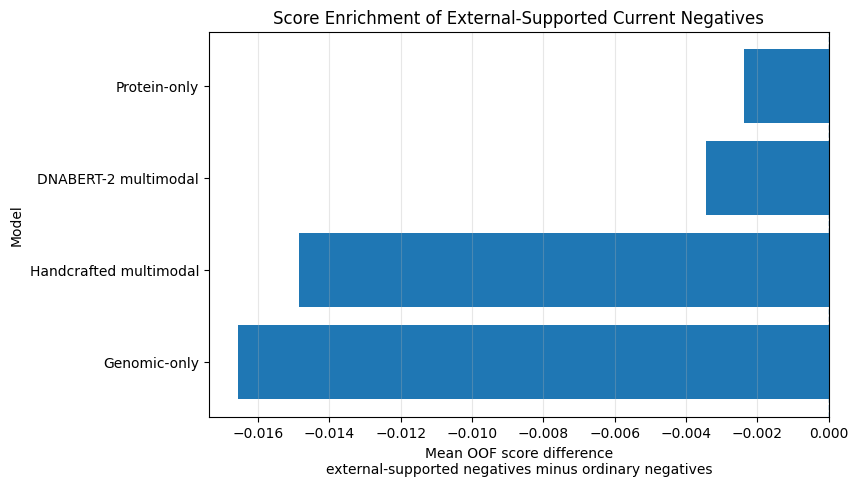

Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/figures/phase19b_external_supported_negative_score_enrichment.png


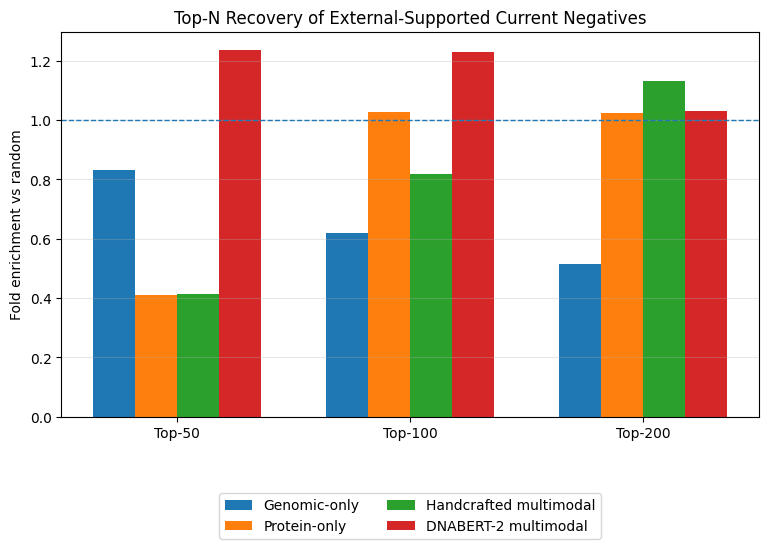

Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/figures/phase19b_topn_external_supported_negative_recovery.png


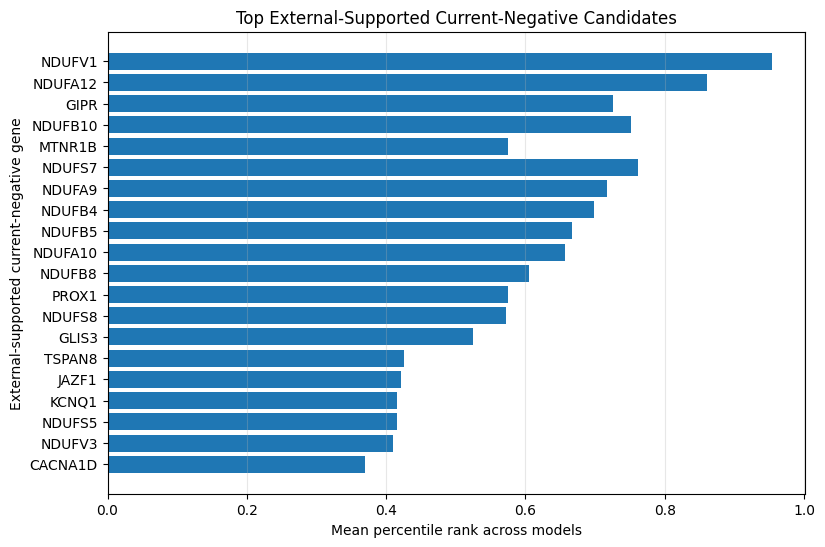

Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/figures/phase19b_top_external_supported_negative_candidates.png


In [9]:
# ============================================================
# FIGURE 1 — EXTERNAL-SUPPORTED NEGATIVE SCORE ENRICHMENT
# ============================================================

plot_df = negative_enrichment_df.copy()
plot_df = plot_df.sort_values("delta_mean_score", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["display_name"], plot_df["delta_mean_score"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Mean OOF score difference\nexternal-supported negatives minus ordinary negatives")
plt.ylabel("Model")
plt.title("Score Enrichment of External-Supported Current Negatives")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase19b_external_supported_negative_score_enrichment.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ============================================================
# FIGURE 2 — TOP-N EXTERNAL-SUPPORTED NEGATIVE RECOVERY
# ============================================================

plot_df = negative_topn_df[negative_topn_df["top_n_negative_ranked"].isin([50, 100, 200])].copy()

model_order = [
    "Genomic-only",
    "Protein-only",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

topn_order = [50, 100, 200]

x = np.arange(len(topn_order))
width = 0.18

plt.figure(figsize=(9, 5))

for i, model in enumerate(model_order):
    sub = plot_df[plot_df["display_name"] == model]
    vals = []

    for top_n in topn_order:
        row = sub[sub["top_n_negative_ranked"] == top_n]
        vals.append(float(row["fold_enrichment_vs_random"].iloc[0]) if not row.empty else np.nan)

    plt.bar(
        x + (i - 1.5) * width,
        vals,
        width=width,
        label=model
    )

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xticks(x, [f"Top-{n}" for n in topn_order])
plt.ylabel("Fold enrichment vs random")
plt.title("Top-N Recovery of External-Supported Current Negatives")
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18))

out_path = FIGURE_DIR / "phase19b_topn_external_supported_negative_recovery.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ============================================================
# FIGURE 3 — HIGH PRIORITY RELABEL CANDIDATES
# ============================================================

plot_df = priority_df.head(20).copy()

plt.figure(figsize=(9, 6))
plt.barh(
    plot_df["gene_symbol"][::-1],
    plot_df["mean_percentile_rank"][::-1]
)
plt.xlabel("Mean percentile rank across models")
plt.ylabel("External-supported current-negative gene")
plt.title("Top External-Supported Current-Negative Candidates")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase19b_top_external_supported_negative_candidates.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [10]:
# ============================================================
# MANUSCRIPT-READY WORDING
# ============================================================

top_priority = priority_df.head(8)["gene_symbol"].tolist()

methods_text = """
Because disease-gene labels are incomplete, an additional label-contamination-aware audit was performed after external gene-set validation. External-supported genes that were labelled negative in the current dataset were identified and ranked using out-of-fold model scores. The analysis tested whether these external-supported current negatives received higher model scores than ordinary negatives, and whether top-ranked negative-labelled genes were enriched for external evidence compared with random negative-gene baselines. This audit was used to distinguish likely background negatives from potential unknown positives or annotation-incomplete candidates.
""".strip()

results_text = f"""
External gene-set validation did not show strong global enrichment after multiple-testing correction. However, the label audit identified several current-negative genes with independent external support and relatively high model ranks. High-priority candidates included {', '.join(top_priority)}. These genes should not be interpreted as ordinary false positives. Instead, they represent possible unknown positives, annotation-incomplete genes or pathway-level candidates that expose the limitations of binary disease-gene labelling.
""".strip()

discussion_text = """
The external-supported negative audit changes the interpretation of weak external validation. Rather than treating all negative-labelled external genes as model errors, the results indicate that the negative class contains biologically plausible genes with independent support. This is expected in disease-gene prioritization, where the absence of curated disease evidence does not guarantee true non-association. Therefore, model performance should be interpreted as ranking utility under incomplete labels rather than definitive disease/non-disease classification. This strengthens the manuscript by explicitly addressing negative-label uncertainty and by identifying relabel or follow-up candidates for future validation.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Label-Contamination-Aware External Audit", "text": methods_text},
    {"section": "Results - External-Supported Current Negatives", "text": results_text},
    {"section": "Discussion - Incomplete Negative Labels", "text": discussion_text},
])

display(wording_df)

save_df(
    wording_df,
    RESULT_DIR / "phase19b_manuscript_ready_wording.csv"
)

with open(REPORT_DIR / "phase19b_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Label-Contamination-Aware External Audit,"Because disease-gene labels are incomplete, an additional label-contamination-aware audit was performed after external gene-set validation. External-supported genes that were labelled negative in the current dataset were identified and ranked using out-of-fold model scores. The analysis tested whether these external-supported current negatives received higher model scores than ordinary negativ..."
1,Results - External-Supported Current Negatives,"External gene-set validation did not show strong global enrichment after multiple-testing correction. However, the label audit identified several current-negative genes with independent external support and relatively high model ranks. High-priority candidates included NDUFV1, NDUFA12, GIPR, NDUFB10, MTNR1B, NDUFS7, NDUFA9, NDUFB4. These genes should not be interpreted as ordinary false positi..."
2,Discussion - Incomplete Negative Labels,"The external-supported negative audit changes the interpretation of weak external validation. Rather than treating all negative-labelled external genes as model errors, the results indicate that the negative class contains biologically plausible genes with independent support. This is expected in disease-gene prioritization, where the absence of curated disease evidence does not guarantee true..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_manuscript_ready_wording.csv
Saved manuscript wording.


In [11]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase19b_external_supported_negative_audit_tables.xlsx"

tables = {
    "External_Strength": external_strength_df,
    "Label_Audit_Summary": label_audit_summary_df,
    "External_Neg_Consensus": external_supported_negatives_consensus_df,
    "Negative_Enrichment": negative_enrichment_df,
    "TopN_Negative_Recovery": negative_topn_df,
    "Priority_Relabel_Candidates": priority_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/excel/phase19b_external_supported_negative_audit_tables.xlsx


In [12]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 19B COMPLETE ===")

print("\nLabel audit summary:")
display(label_audit_summary_df)

print("\nNegative-only score enrichment:")
display(negative_enrichment_df)

print("\nTop-N external-supported negative recovery:")
display(negative_topn_df)

print("\nHigh-priority relabel candidates:")
display(priority_df.head(50))

print("\nWording:")
display(wording_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 19B COMPLETE ===

Label audit summary:


,true_label,is_external_supported,n_genes,median_consensus_rank,median_percentile
0,0,False,859,1184.0,0.36939
1,0,True,44,1333.0,0.29612
2,1,False,856,621.5,0.62999
3,1,True,47,500.0,0.68712



Negative-only score enrichment:


,model_name,display_name,n_external_supported_negatives,n_ordinary_negatives,mean_score_external_supported_negatives,mean_score_ordinary_negatives,delta_mean_score,median_rank_external_supported_negatives,median_rank_ordinary_negatives,mannwhitney_two_sided_p,mannwhitney_greater_p,top_external_supported_negative_genes,bh_fdr_two_sided,bh_fdr_greater
0,DNABERT2_multimodal,DNABERT-2 multimodal,44,859,0.41692,0.42036,-0.00344,1212.0,1197.0,0.88947,0.55550,NDUFV1; NDUFA12; NDUFB10; NDUFB5; GIPR; NDUFA9; NDUFA10; NDUFS7; NDUFB4; NDUFB8,0.94401,0.88239
1,Genomic_only_K3K4Basic,Genomic-only,44,859,0.46055,0.47709,-0.01655,1144.5,1073.0,0.23545,0.88239,NDUFA12; NDUFV1; MTNR1B; NDUFB4; NDUFS7; NDUFB3; PAX4; JAZF1; NDUFA9; GIPR,0.94179,0.88239
2,Handcrafted_multimodal,Handcrafted multimodal,44,859,0.40926,0.42410,-0.01484,1327.0,1181.0,0.47901,0.76068,NDUFV1; NDUFS7; NDUFA12; NDUFB10; NDUFA9; NDUFB8; GIPR; NDUFB5; NDUFB4; NDUFA10,0.94401,0.88239
3,Protein_only_ProtBERT_SW,Protein-only,44,859,0.43061,0.43299,-0.00239,1198.5,1182.0,0.94401,0.52823,NDUFV1; NDUFB8; GIPR; NDUFB10; GLIS3; NDUFS7; NDUFA9; NDUFB5; NDUFA10; NDUFA12,0.94401,0.88239



Top-N external-supported negative recovery:


...


High-priority relabel candidates:


,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,best_model_rank,best_model,best_model_score,n_external_sets,external_evidence_strength,external_sets,relabel_audit_priority
0,NDUFV1,0,22,0.95374,28,28,Handcrafted multimodal,0.83123,1,single_source,Mitochondrial_OXPHOS_complex_I,high
1,NDUFA12,0,158,0.85997,30,30,Genomic-only,0.71657,1,single_source,Mitochondrial_OXPHOS_complex_I,high
2,GIPR,0,413,0.72548,348,348,Protein-only,0.68563,3,high_multi_source,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high
42,NDUFB10,0,360,0.75208,198,198,DNABERT-2 multimodal,0.76245,1,single_source,Mitochondrial_OXPHOS_complex_I,moderate
43,MTNR1B,0,743,0.57562,267,267,Genomic-only,0.61268,2,moderate_two_source,Beta_cell_function_or_development; Known_T2D_GWAS_or_genetic_risk,moderate
3,NDUFS7,0,339,0.76136,278,278,Handcrafted multimodal,0.71925,1,single_source,Mitochondrial_OXPHOS_complex_I,low
4,NDUFA9,0,431,0.71731,423,423,Protein-only,0.66055,1,single_source,Mitochondrial_OXPHOS_complex_I,low
5,NDUFB4,0,470,0.69820,359,359,Genomic-only,0.58588,1,single_source,Mitochondrial_OXPHOS_complex_I,low
6,NDUFB5,0,539,0.66704,354,354,DNABERT-2 multimodal,0.70097,1,single_source,Mitochondrial_OXPHOS_complex_I,low
7,NDUFA10,0,561,0.65637,456,456,DNABERT-2 multimodal,0.66111,1,single_source,Mitochondrial_OXPHOS_complex_I,low



Wording:


,section,text
0,Methods - Label-Contamination-Aware External Audit,"Because disease-gene labels are incomplete, an additional label-contamination-aware audit was performed after external gene-set validation. External-supported genes that were labelled negative in the current dataset were identified and ranked using out-of-fold model scores. The analysis tested whether these external-supported current negatives received higher model scores than ordinary negativ..."
1,Results - External-Supported Current Negatives,"External gene-set validation did not show strong global enrichment after multiple-testing correction. However, the label audit identified several current-negative genes with independent external support and relatively high model ranks. High-priority candidates included NDUFV1, NDUFA12, GIPR, NDUFB10, MTNR1B, NDUFS7, NDUFA9, NDUFB4. These genes should not be interpreted as ordinary false positi..."
2,Discussion - Incomplete Negative Labels,"The external-supported negative audit changes the interpretation of weak external validation. Rather than treating all negative-labelled external genes as model errors, the results indicate that the negative class contains biologically plausible genes with independent support. This is expected in disease-gene prioritization, where the absence of curated disease evidence does not guarantee true..."



Figures:
/content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/figures/phase19b_external_supported_negative_score_enrichment.png
/content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/figures/phase19b_top_external_supported_negative_candidates.png
/content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/figures/phase19b_topn_external_supported_negative_recovery.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_external_evidence_strength_by_gene.csv
/content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_external_supported_current_negatives_consensus_ranked.csv
/content/drive/MyDrive/Project_Protein/model/phase19b_external_supported_negative_audit/results/phase19b_high_priority_external_supported_negative_relabel_candidates.csv
/content/drive/MyDrive/Project_Protein/model/p

In [13]:
display(label_audit_summary_df)

display(negative_enrichment_df)

display(negative_topn_df)

display(priority_df.head(50))

,true_label,is_external_supported,n_genes,median_consensus_rank,median_percentile
0,0,False,859,1184.0,0.36939
1,0,True,44,1333.0,0.29612
2,1,False,856,621.5,0.62999
3,1,True,47,500.0,0.68712


,model_name,display_name,n_external_supported_negatives,n_ordinary_negatives,mean_score_external_supported_negatives,mean_score_ordinary_negatives,delta_mean_score,median_rank_external_supported_negatives,median_rank_ordinary_negatives,mannwhitney_two_sided_p,mannwhitney_greater_p,top_external_supported_negative_genes,bh_fdr_two_sided,bh_fdr_greater
0,DNABERT2_multimodal,DNABERT-2 multimodal,44,859,0.41692,0.42036,-0.00344,1212.0,1197.0,0.88947,0.55550,NDUFV1; NDUFA12; NDUFB10; NDUFB5; GIPR; NDUFA9; NDUFA10; NDUFS7; NDUFB4; NDUFB8,0.94401,0.88239
1,Genomic_only_K3K4Basic,Genomic-only,44,859,0.46055,0.47709,-0.01655,1144.5,1073.0,0.23545,0.88239,NDUFA12; NDUFV1; MTNR1B; NDUFB4; NDUFS7; NDUFB3; PAX4; JAZF1; NDUFA9; GIPR,0.94179,0.88239
2,Handcrafted_multimodal,Handcrafted multimodal,44,859,0.40926,0.42410,-0.01484,1327.0,1181.0,0.47901,0.76068,NDUFV1; NDUFS7; NDUFA12; NDUFB10; NDUFA9; NDUFB8; GIPR; NDUFB5; NDUFB4; NDUFA10,0.94401,0.88239
3,Protein_only_ProtBERT_SW,Protein-only,44,859,0.43061,0.43299,-0.00239,1198.5,1182.0,0.94401,0.52823,NDUFV1; NDUFB8; GIPR; NDUFB10; GLIS3; NDUFS7; NDUFA9; NDUFB5; NDUFA10; NDUFA12,0.94401,0.88239


,model_name,display_name,top_n_negative_ranked,observed_external_supported_negatives,random_mean,random_sd,fold_enrichment_vs_random,empirical_p,external_supported_negative_genes_in_topn,empirical_bh_fdr_global,empirical_bh_fdr_within_topn
0,DNABERT2_multimodal,DNABERT-2 multimodal,25,2,1.2118,1.05203,1.65044,0.34473,NDUFA12; NDUFV1,0.97223,0.72306
1,DNABERT2_multimodal,DNABERT-2 multimodal,50,3,2.4260,1.50631,1.23660,0.44191,NDUFA12; NDUFB10; NDUFV1,0.97223,0.92362
2,DNABERT2_multimodal,DNABERT-2 multimodal,100,6,4.8782,2.00603,1.22996,0.35373,GIPR; NDUFA12; NDUFA9; NDUFB10; NDUFB5; NDUFV1,0.97223,0.88142
3,DNABERT2_multimodal,DNABERT-2 multimodal,150,8,7.3574,2.42298,1.08734,0.46411,GIPR; NDUFA10; NDUFA12; NDUFA9; NDUFB10; NDUFB5; NDUFS7; NDUFV1,0.97223,0.61881
4,DNABERT2_multimodal,DNABERT-2 multimodal,200,10,9.7140,2.70652,1.02944,0.52110,GIPR; NDUFA10; NDUFA12; NDUFA9; NDUFB10; NDUFB4; NDUFB5; NDUFB8; NDUFS7; NDUFV1,0.97223,0.69799
5,Genomic_only_K3K4Basic,Genomic-only,25,1,1.2356,1.07290,0.80932,0.72306,NDUFA12,0.97223,0.72306
6,Genomic_only_K3K4Basic,Genomic-only,50,2,2.4046,1.47856,0.83174,0.71326,NDUFA12; NDUFV1,0.97223,0.92362
7,Genomic_only_K3K4Basic,Genomic-only,100,3,4.8408,2.03241,0.61973,0.88142,MTNR1B; NDUFA12; NDUFV1,0.97223,0.88142
8,Genomic_only_K3K4Basic,Genomic-only,150,5,7.2842,2.40437,0.68642,0.87542,MTNR1B; NDUFA12; NDUFB4; NDUFS7; NDUFV1,0.97223,0.87542
9,Genomic_only_K3K4Basic,Genomic-only,200,5,9.7228,2.66176,0.51426,0.98560,MTNR1B; NDUFA12; NDUFB4; NDUFS7; NDUFV1,0.98560,0.98560


,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,best_model_rank,best_model,best_model_score,n_external_sets,external_evidence_strength,external_sets,relabel_audit_priority
0,NDUFV1,0,22,0.95374,28,28,Handcrafted multimodal,0.83123,1,single_source,Mitochondrial_OXPHOS_complex_I,high
1,NDUFA12,0,158,0.85997,30,30,Genomic-only,0.71657,1,single_source,Mitochondrial_OXPHOS_complex_I,high
2,GIPR,0,413,0.72548,348,348,Protein-only,0.68563,3,high_multi_source,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,high
42,NDUFB10,0,360,0.75208,198,198,DNABERT-2 multimodal,0.76245,1,single_source,Mitochondrial_OXPHOS_complex_I,moderate
43,MTNR1B,0,743,0.57562,267,267,Genomic-only,0.61268,2,moderate_two_source,Beta_cell_function_or_development; Known_T2D_GWAS_or_genetic_risk,moderate
3,NDUFS7,0,339,0.76136,278,278,Handcrafted multimodal,0.71925,1,single_source,Mitochondrial_OXPHOS_complex_I,low
4,NDUFA9,0,431,0.71731,423,423,Protein-only,0.66055,1,single_source,Mitochondrial_OXPHOS_complex_I,low
5,NDUFB4,0,470,0.69820,359,359,Genomic-only,0.58588,1,single_source,Mitochondrial_OXPHOS_complex_I,low
6,NDUFB5,0,539,0.66704,354,354,DNABERT-2 multimodal,0.70097,1,single_source,Mitochondrial_OXPHOS_complex_I,low
7,NDUFA10,0,561,0.65637,456,456,DNABERT-2 multimodal,0.66111,1,single_source,Mitochondrial_OXPHOS_complex_I,low
